In [ ]:
import sys

# Install with NO version pins — pip resolves the latest compatible stack
!{sys.executable} -m pip install -q \
    spatialdata \
    spatialdata-io \
    squidpy \
    scanpy \
    seaborn \
    leidenalg

print("\n Installation complete.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 3.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 4.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 6.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.8/87.8 kB 6.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 192.3/192.3 kB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.8/97.8 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.9/193.9 kB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 43.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 58.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 174.3/174.3 kB 13.4 MB/s e

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import anndata as ad
import scanpy as sc
import squidpy as sq
import spatialdata as sd
from spatialdata_io import xenium

sc.settings.verbosity = 1

print(f"scanpy       : {sc.__version__}")
print(f"squidpy      : {sq.__version__}")
print(f"spatialdata  : {sd.__version__}")
print(f"anndata      : {ad.__version__}")

scanpy       : 1.12.1
squidpy      : 1.8.1
spatialdata  : 0.7.2
anndata      : 0.12.11


In [ ]:
XENIUM_DIR = "./Xenium"
ZIP_FILE   = "Xenium_outs.zip"
URL = (
    "https://cf.10xgenomics.com/samples/xenium/2.0.0/"
    "Xenium_V1_human_Lung_2fov/Xenium_V1_human_Lung_2fov_outs.zip"
)

if not os.path.exists(XENIUM_DIR):
    print("Downloading dataset (~3 GB) — may take 5–15 min ...")
    !wget -q --show-progress "{URL}" -O "{ZIP_FILE}"
    print("Extracting ...")
    !unzip -q "{ZIP_FILE}" -d "{XENIUM_DIR}"
    !rm -f "{ZIP_FILE}"
    print("Done!")
else:
    print("Xenium/ already exists — skipping download.")

print("\nFolder contents:")
!ls "{XENIUM_DIR}"

Xenium_outs.zip     100%[===================>] 265.12M   221MB/s    in 1.2s    
Extracting ...
Done!

Folder contents:
analysis_summary.html	      cells.zarr.zip
analysis.tar.gz		      experiment.xenium
analysis.zarr.zip	      gene_panel.json
aux_outputs.tar.gz	      metrics_summary.csv
cell_boundaries.csv.gz	      morphology_focus
cell_boundaries.parquet       morphology.ome.tif
cell_feature_matrix.h5	      nucleus_boundaries.csv.gz
cell_feature_matrix.tar.gz    nucleus_boundaries.parquet
cell_feature_matrix.zarr.zip  transcripts.csv.gz
cells.csv.gz		      transcripts.parquet
cells.parquet		      transcripts.zarr.zip


In [ ]:
print("Loading Xenium data into memory (no images, no Zarr write) ...")

sdata = xenium(
    XENIUM_DIR,
    morphology_focus=False,   # skip: causes Zarr chunk error
    morphology_mip=False,     # skip: causes Zarr chunk error
    aligned_images=False,     # skip: any aligned H&E or IF images
    transcripts=False,        # skip: raw transcript point cloud (very large)
)

print("\nLoaded successfully:")
print(sdata)

Loading Xenium data into memory (no images, no Zarr write) ...

Loaded successfully:
SpatialData object
├── Labels
│     ├── 'cell_labels': DataTree[yx] (3553, 5791), (1776, 2895), (888, 1447), (444, 723), (222, 361)
│     └── 'nucleus_labels': DataTree[yx] (3553, 5791), (1776, 2895), (888, 1447), (444, 723), (222, 361)
├── Shapes
│     ├── 'cell_boundaries': GeoDataFrame shape: (11898, 1) (2D shapes)
│     ├── 'cell_circles': GeoDataFrame shape: (11898, 2) (2D shapes)
│     └── 'nucleus_boundaries': GeoDataFrame shape: (11898, 1) (2D shapes)
└── Tables
      └── 'table': AnnData (11898, 289)
with coordinate systems:
    ▸ 'global', with elements:
        cell_labels (Labels), nucleus_labels (Labels), cell_boundaries (Shapes), cell_circles (Shapes), nucleus_boundaries (Shapes)


In [ ]:
# Safely get the table regardless of key name
table_keys = list(sdata.tables.keys())
print(f"Available table keys: {table_keys}")

adata = sdata.tables[table_keys[0]]
print(f"\nUsing table: '{table_keys[0]}'")
print(adata)
print("\nObs columns:", adata.obs.columns.tolist())

Available table keys: ['table']

Using table: 'table'
AnnData object with n_obs × n_vars = 11898 × 289
    obs: 'cell_id', 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'region', 'z_level', 'nucleus_count', 'cell_labels'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatialdata_attrs'
    obsm: 'spatial'

Obs columns: ['cell_id', 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'region', 'z_level', 'nucleus_count', 'cell_labels']


In [ ]:
# Preview per-cell metadata
adata.obs.head()

,cell_id,transcript_counts,control_probe_counts,control_codeword_counts,unassigned_codeword_counts,deprecated_codeword_counts,total_counts,cell_area,nucleus_area,region,z_level,nucleus_count,cell_labels
0,aaafiiei-1,67,0,0,0,0,67,139.126411,29.125782,cell_circles,5.0,1.0,1
1,aaanbaof-1,69,0,0,0,0,69,154.434381,31.519064,cell_circles,5.0,1.0,2
2,aabdiein-1,63,0,0,0,0,63,148.247974,25.693907,cell_circles,5.0,1.0,3
3,aabfemmf-1,78,0,0,0,0,78,120.251098,33.551095,cell_circles,5.0,1.0,4
4,aacflbgf-1,19,0,0,0,0,19,31.067501,8.128125,cell_circles,5.0,1.0,5


In [ ]:
# Verify spatial coordinates are populated
# (spatialdata-io xenium reader sets obsm["spatial"] automatically)
if "spatial" in adata.obsm:
    print("Spatial coords shape:", adata.obsm["spatial"].shape)
    print(adata.obsm["spatial"][:3])
else:
    # Fallback: build from centroid obs columns
    x_col = next((c for c in adata.obs.columns if "x_centroid" in c.lower()), None)
    y_col = next((c for c in adata.obs.columns if "y_centroid" in c.lower()), None)
    if x_col and y_col:
        adata.obsm["spatial"] = np.column_stack(
            [adata.obs[x_col].values, adata.obs[y_col].values]
        )
        print(f"Built spatial coords from '{x_col}' and '{y_col}'")
    else:
        print("WARNING: Could not find spatial coordinates.")
        print("Available obs columns:", adata.obs.columns.tolist())

Spatial coords shape: (11898, 2)
[[ 37.24629974 667.76745605]
 [ 44.10276031 701.72283936]
 [ 40.73135757 684.13360596]]


In [ ]:
sc.pp.calculate_qc_metrics(adata, percent_top=(10, 20, 50, 150), inplace=True)

for col in ["control_probe_counts", "control_codeword_counts"]:
    if col in adata.obs.columns:
        pct = adata.obs[col].sum() / adata.obs["total_counts"].sum() * 100
        print(f"{col}: {pct:.4f}%  (good if < 1%)")

control_probe_counts: 0.0025%  (good if < 1%)
control_codeword_counts: 0.0053%  (good if < 1%)


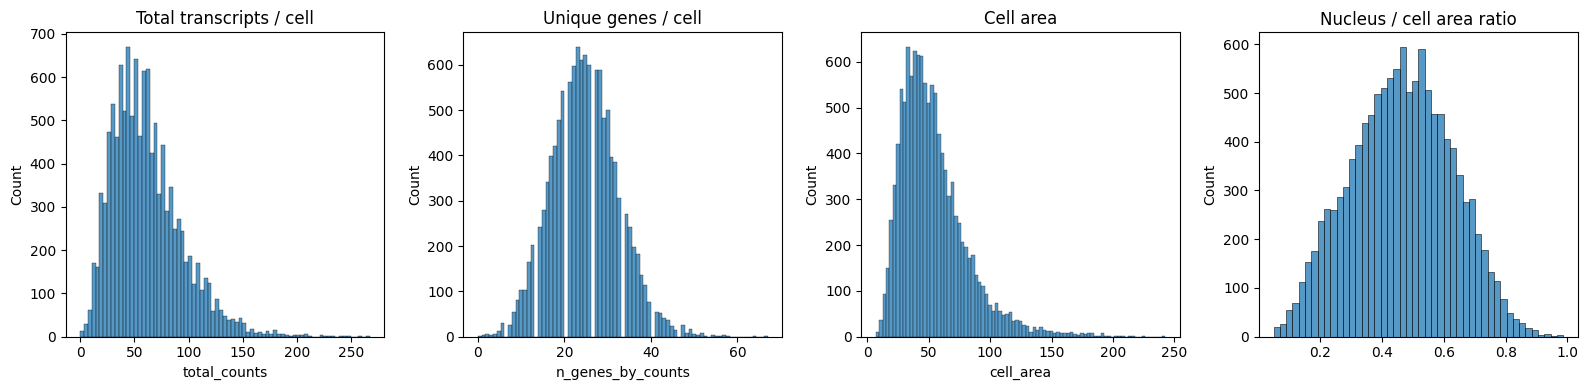

In [ ]:
fig, axs = plt.subplots(1, 4, figsize=(16, 4))

axs[0].set_title("Total transcripts / cell")
sns.histplot(adata.obs["total_counts"], kde=False, ax=axs[0])

axs[1].set_title("Unique genes / cell")
sns.histplot(adata.obs["n_genes_by_counts"], kde=False, ax=axs[1])

if "cell_area" in adata.obs.columns:
    axs[2].set_title("Cell area")
    sns.histplot(adata.obs["cell_area"], kde=False, ax=axs[2])
else:
    axs[2].set_visible(False)

if "nucleus_area" in adata.obs.columns and "cell_area" in adata.obs.columns:
    axs[3].set_title("Nucleus / cell area ratio")
    sns.histplot(adata.obs["nucleus_area"] / adata.obs["cell_area"], kde=False, ax=axs[3])
else:
    axs[3].set_visible(False)

plt.tight_layout()
plt.show()

In [ ]:
print(f"Before: {adata.n_obs:>8,} cells | {adata.n_vars:>5,} genes")

sc.pp.filter_cells(adata, min_counts=10)
sc.pp.filter_genes(adata, min_cells=5)

print(f"After : {adata.n_obs:>8,} cells | {adata.n_vars:>5,} genes")

Before:   11,898 cells |   289 genes
After :   11,820 cells |   285 genes


In [ ]:
adata.layers["counts"] = adata.X.copy()   # preserve raw counts

sc.pp.normalize_total(adata, inplace=True)
sc.pp.log1p(adata)
sc.pp.pca(adata)
sc.pp.neighbors(adata)
sc.tl.umap(adata)
sc.tl.leiden(adata)

print(f"Leiden clusters found: {adata.obs['leiden'].nunique()}")

Leiden clusters found: 13


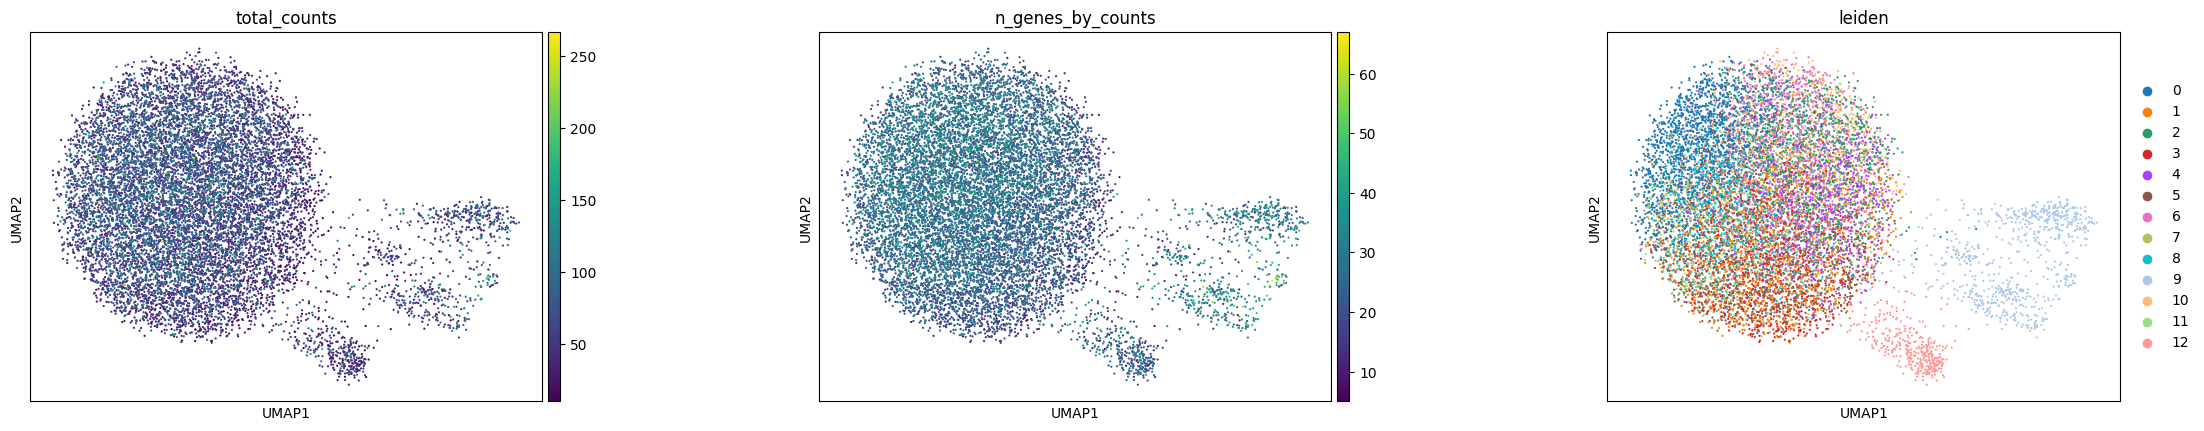

In [ ]:
sc.pl.umap(
    adata,
    color=["total_counts", "n_genes_by_counts", "leiden"],
    wspace=0.4,
)

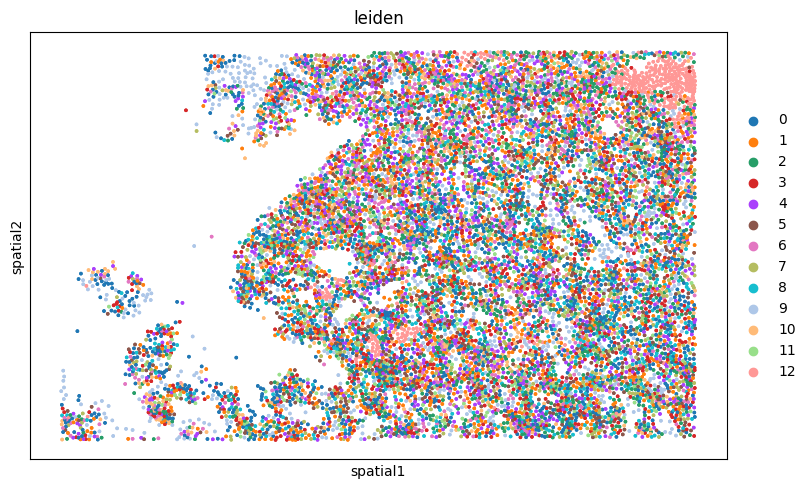

In [ ]:
sq.pl.spatial_scatter(
    adata,
    library_id="spatial",
    shape=None,
    color=["leiden"],
    figsize=(8, 8),
)

In [ ]:
sq.gr.spatial_neighbors(adata, coord_type="generic", delaunay=True)

print("Spatial graph built.")
print("Connectivities matrix shape:", adata.obsp["spatial_connectivities"].shape)

INFO     Creating graph using `generic` coordinates and `None` transform and `1` libraries.                        
Spatial graph built.
Connectivities matrix shape: (11820, 11820)


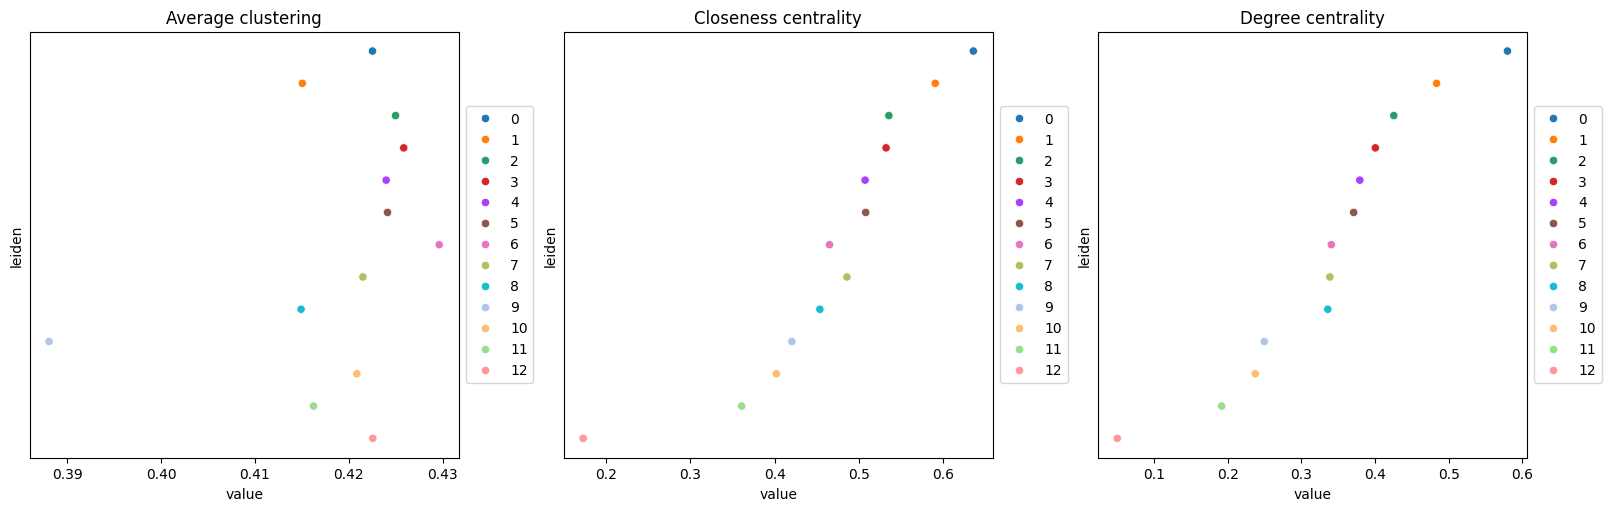

In [ ]:
sq.gr.centrality_scores(adata, cluster_key="leiden")
sq.pl.centrality_scores(adata, cluster_key="leiden", figsize=(16, 5))

In [ ]:
adata_sub = sc.pp.subsample(adata, fraction=0.5, copy=True)

print(f"Full dataset : {adata.n_obs:,} cells")
print(f"Subsampled   : {adata_sub.n_obs:,} cells")

Full dataset : 11,820 cells
Subsampled   : 5,910 cells


Conditioning on cluster: 3


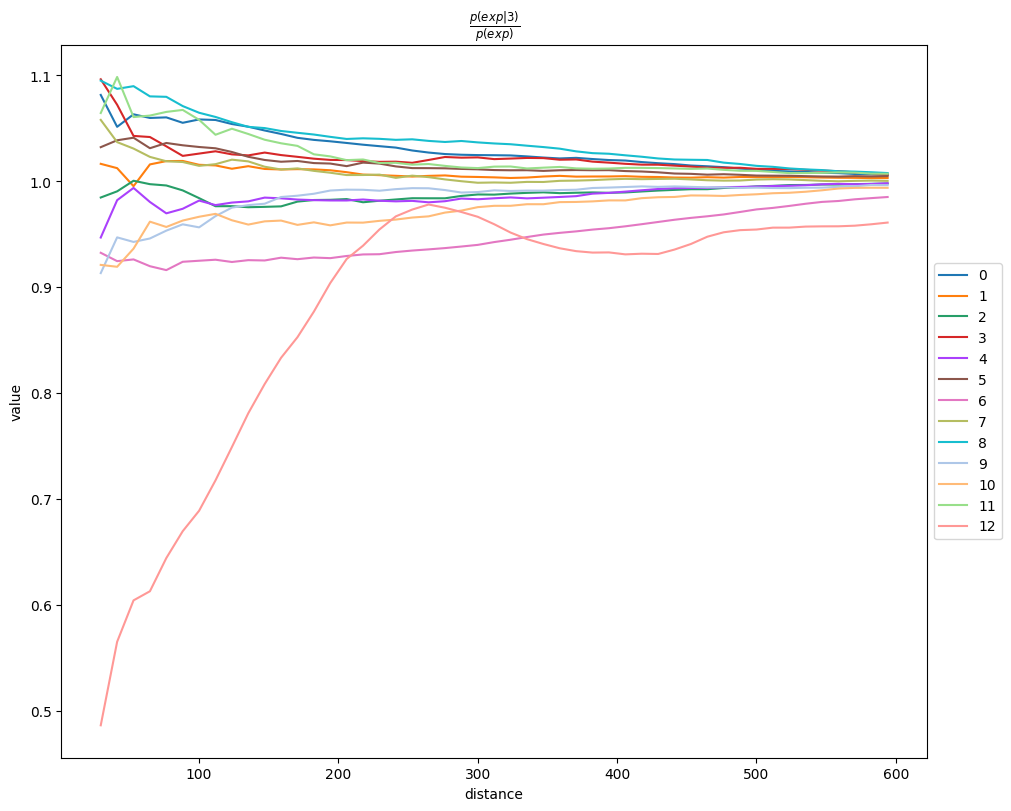

In [ ]:
sq.gr.co_occurrence(adata_sub, cluster_key="leiden")

# Pick a cluster guaranteed to exist
clusters_sorted = sorted(adata_sub.obs["leiden"].unique().tolist(), key=int)
cond_cluster = clusters_sorted[min(3, len(clusters_sorted) - 1)]
print(f"Conditioning on cluster: {cond_cluster}")

sq.pl.co_occurrence(
    adata_sub,
    cluster_key="leiden",
    clusters=cond_cluster,
    figsize=(10, 8),
)

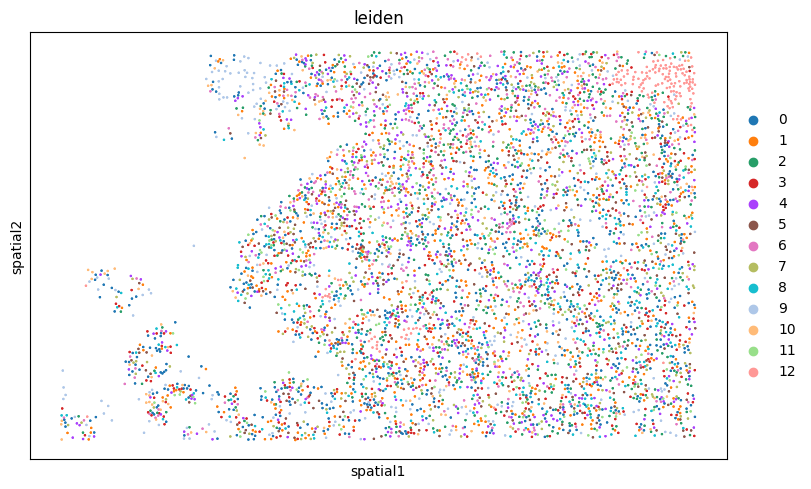

In [ ]:
# Spatial scatter of subsampled cells coloured by cluster
sq.pl.spatial_scatter(
    adata_sub,
    color="leiden",
    shape=None,
    size=2,
    figsize=(8, 8),
)

In [ ]:
sq.gr.nhood_enrichment(adata, cluster_key="leiden")
print("Neighbourhood enrichment complete.")

  0%|          | 0/1000 [00:00<?, ?/s]

Neighbourhood enrichment complete.


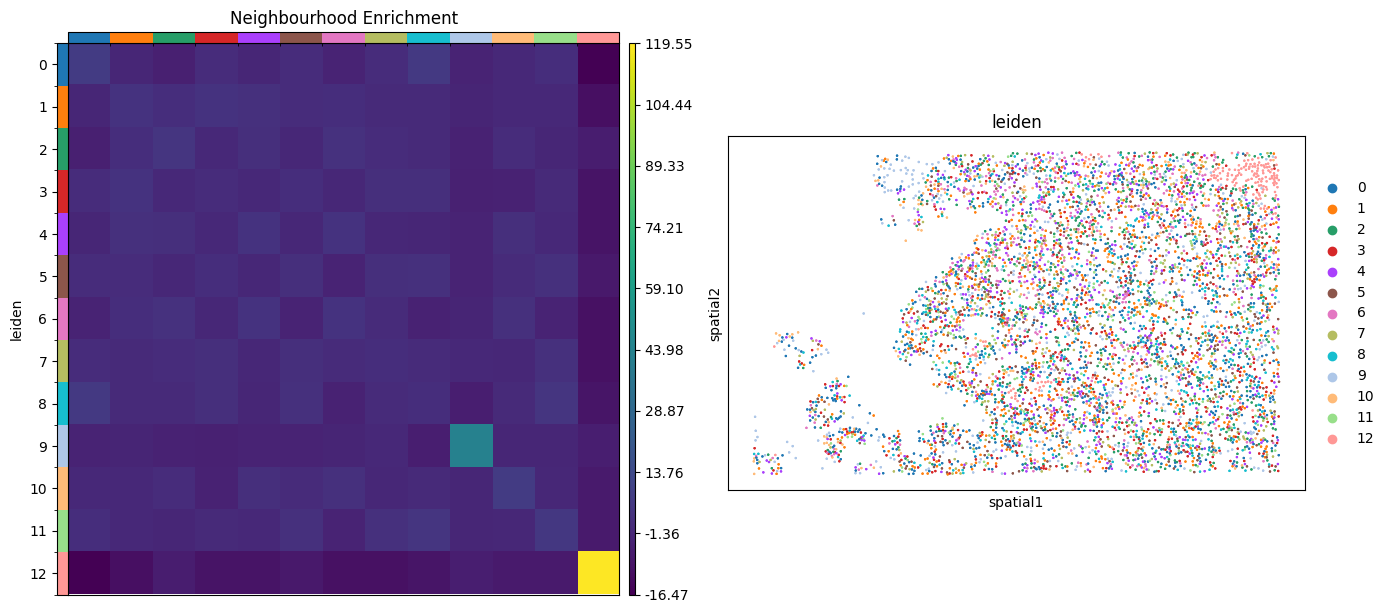

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(14, 7))

sq.pl.nhood_enrichment(
    adata,
    cluster_key="leiden",
    title="Neighbourhood Enrichment",
    ax=ax[0],
)

sq.pl.spatial_scatter(
    adata_sub,
    color="leiden",
    shape=None,
    size=2,
    ax=ax[1],
)

plt.tight_layout()
plt.show()

## Cell 17 — Moran's I: Spatially Variable Genes

Moran's I detects genes with **spatially structured expression**:

| Value | Meaning |
|-------|---------|
| ≈ +1 | Strongly clustered — nearby cells share similar expression |
| ≈ 0 | Random distribution across tissue |
| ≈ −1 | Dispersed / checkerboard pattern |

We rebuild the spatial graph on the subsampled data and compute across all genes.

In [ ]:
# Spatial graph on subsampled data
sq.gr.spatial_neighbors(adata_sub, coord_type="generic", delaunay=True)

# Compute Moran's I (100 permutations for significance testing)
sq.gr.spatial_autocorr(
    adata_sub,
    mode="moran",
    n_perms=100,
    n_jobs=1,
)

print("Top 10 spatially variable genes:")
adata_sub.uns["moranI"].head(10)

INFO     Creating graph using `generic` coordinates and `None` transform and `1` libraries.                        


  0%|          | 0/100 [00:00<?, ?/s]

Top 10 spatially variable genes:


,I,pval_norm,var_norm,pval_z_sim,pval_sim,var_sim,pval_norm_fdr_bh,pval_z_sim_fdr_bh,pval_sim_fdr_bh
IGFBP3,0.386782,0.0,0.000057,0.0,0.009901,0.000060,0.0,0.0,0.023515
GJA5,0.367843,0.0,0.000057,0.0,0.009901,0.000062,0.0,0.0,0.023515
CXCL13,0.277089,0.0,0.000057,0.0,0.009901,0.000064,0.0,0.0,0.023515
PLA2G7,0.232207,0.0,0.000057,0.0,0.009901,0.000061,0.0,0.0,0.023515
GPX2,0.223969,0.0,0.000057,0.0,0.009901,0.000051,0.0,0.0,0.023515
ANPEP,0.219542,0.0,0.000057,0.0,0.009901,0.000054,0.0,0.0,0.023515
MYH11,0.207796,0.0,0.000057,0.0,0.009901,0.000034,0.0,0.0,0.023515
LTBP2,0.195293,0.0,0.000057,0.0,0.009901,0.000040,0.0,0.0,0.023515
DIRAS3,0.193210,0.0,0.000057,0.0,0.009901,0.000045,0.0,0.0,0.023515
AGR3,0.165852,0.0,0.000057,0.0,0.009901,0.000052,0.0,0.0,0.023515


## Cell 18 — Visualise Top Spatially Variable Genes

Plot the top 2 genes by Moran's I on the tissue. High Moran's I genes should display clear regional expression patterns.

Top spatially variable genes: ['IGFBP3', 'GJA5']


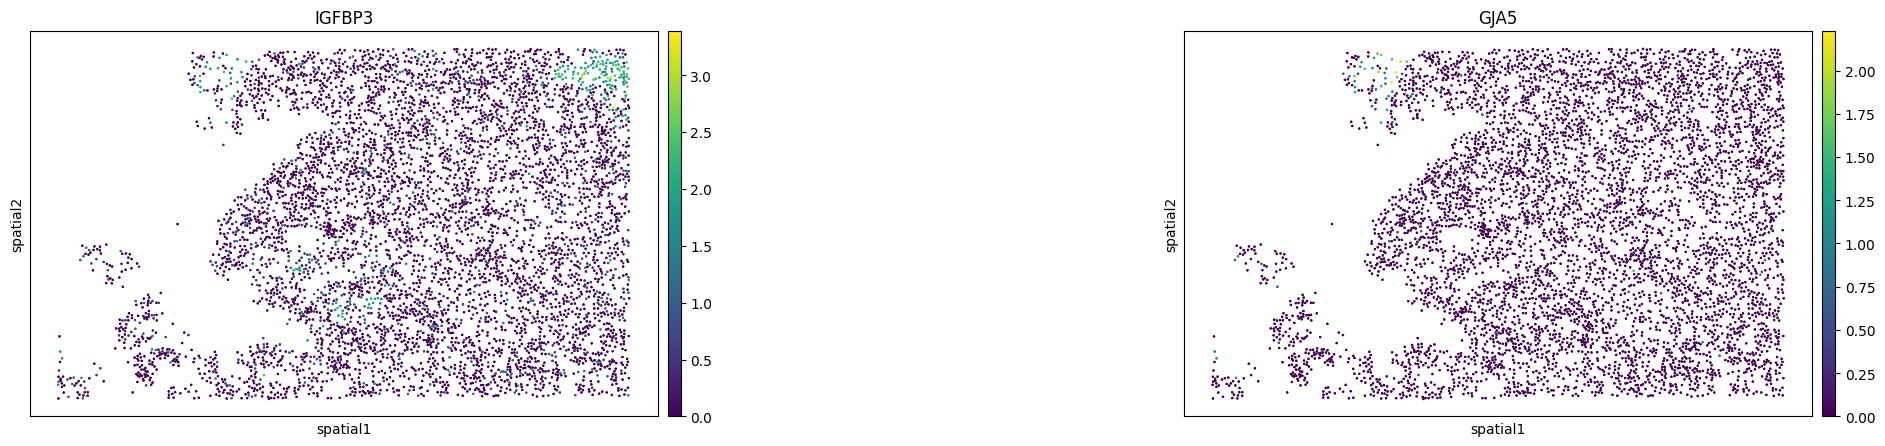

In [ ]:
top_genes = adata_sub.uns["moranI"].index[:2].tolist()
print(f"Top spatially variable genes: {top_genes}")

sq.pl.spatial_scatter(
    adata_sub,
    library_id="spatial",
    color=top_genes,
    shape=None,
    size=2,
    img=False,
    figsize=(12, 5),
)

In [ ]:
print("=== Final AnnData ===")
print(adata)
print("\n=== Stored analysis results ===")
print(list(adata.uns.keys()))

=== Final AnnData ===
AnnData object with n_obs × n_vars = 11820 × 285
    obs: 'cell_id', 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'region', 'z_level', 'nucleus_count', 'cell_labels', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_150_genes', 'n_counts', 'leiden'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells'
    uns: 'spatialdata_attrs', 'log1p', 'pca', 'neighbors', 'umap', 'leiden', 'leiden_colors', 'spatial_neighbors', 'leiden_centrality_scores', 'leiden_nhood_enrichment'
    obsm: 'spatial', 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'distances', 'connectivities', 'sp